# Smart Agriculture Assistant

## Disease Dataset Preprocessing

### Objective
The purpose of this notebook is to prepare the PlantVillage dataset for disease detection model training.

The preprocessing pipeline includes:

- Dataset inspection
- Dataset cleaning
- Class verification
- Image resizing
- Image normalization
- Data augmentation
- Saving the processed dataset

The final processed dataset will be provided to the Disease Detection Model Developer for CNN/VGG16 training.

---

# Libraries Used in This Notebook

| Library | Purpose |
|----------|----------|
| os | Manage folders and file paths |
| cv2 (OpenCV) | Read, resize, and process images |
| numpy | Numerical computations and image arrays |
| pandas | Dataset analysis and tabular data handling |
| PIL | Image loading and visualization |
| tqdm | Progress tracking during processing |
| matplotlib | Plot graphs and display images |
| seaborn | Visualize class distributions |
| ImageDataGenerator | Data augmentation for deep learning |

In [1]:
# Operating system utilities for working with folders and file paths
import os

# OpenCV library used for image reading, resizing, and processing
import cv2

# Numerical computations and array operations
import numpy as np

# Data manipulation and tabular analysis
import pandas as pd

# Image loading and visualization support
from PIL import Image

# Progress bar for long-running loops
from tqdm import tqdm

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Image augmentation utilities from TensorFlow/Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

---

# Load Dataset

The PlantVillage dataset is loaded from the local directory.

In [2]:
import os
print(os.getcwd())

C:\Users\Administrator\Desktop\Ai_LAB_Project


In [3]:
import zipfile

# Replace this with the exact name of the zip file you downloaded
zip_file_path = "archive.zip"  

print("Extracting dataset... Please wait.")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall("PlantVillage_Raw")
print("Extraction complete!")

Extracting dataset... Please wait.
Extraction complete!


In [4]:
import os

raw_path = "PlantVillage_Raw"
print("Contents of PlantVillage_Raw:", os.listdir(raw_path))

Contents of PlantVillage_Raw: ['PlantVillage']


In [5]:
# Section 3 Code Cell
dataset_path = r"PlantVillage_Raw\PlantVillage\PlantVillage"

print("Dataset Path:", dataset_path)

Dataset Path: PlantVillage_Raw\PlantVillage\PlantVillage


---

# Dataset Inspection

This section checks:

- Number of disease classes
- Number of images in each class
- Dataset structure

In [6]:
# Section 4 Code Cell
classes = os.listdir(dataset_path)

print("Total Classes:", len(classes))
print(classes)

Total Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [7]:
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        print(
            f"{class_name}: {len(os.listdir(class_path))} images"
        )

Pepper__bell___Bacterial_spot: 997 images
Pepper__bell___healthy: 1478 images
Potato___Early_blight: 1000 images
Potato___healthy: 152 images
Potato___Late_blight: 1000 images
Tomato_Bacterial_spot: 2127 images
Tomato_Early_blight: 1000 images
Tomato_healthy: 1591 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Target_Spot: 1404 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images


---

# Visualize Sample Images

Displaying sample images helps verify that the dataset is loaded correctly and images belong to the expected classes.

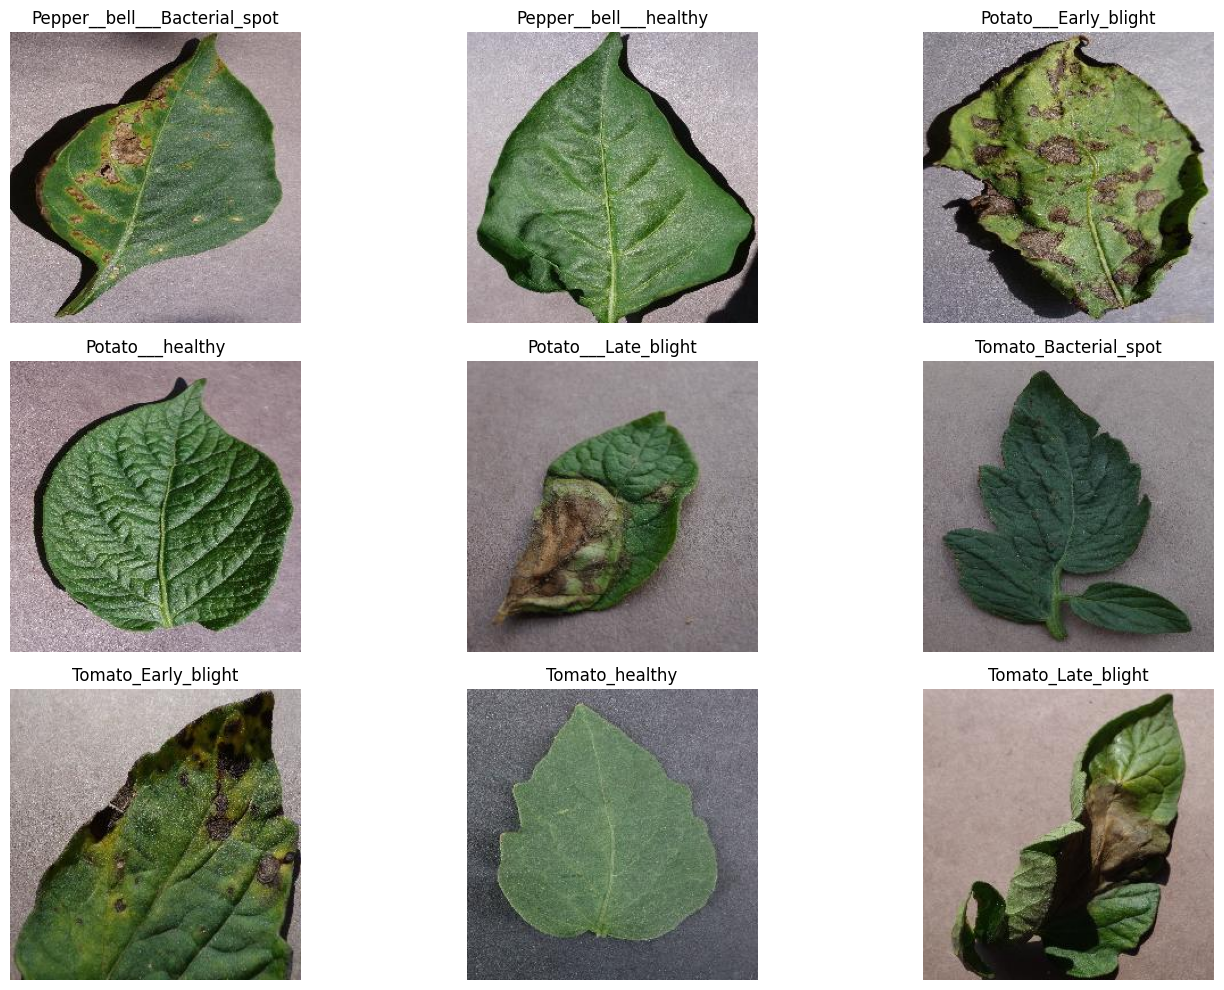

In [9]:
plt.figure(figsize=(15,10))

for i, class_name in enumerate(classes[:9]):

    class_path = os.path.join(dataset_path,class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path,image_name)

    image = Image.open(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

---

# Detect Corrupted Images

Corrupted images can negatively affect model training.

This section identifies unreadable images and removes them.

In [ ]:
corrupted_images = []

for class_name in classes:

    class_path = os.path.join(dataset_path,class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path,image_name)

        try:
            img = cv2.imread(image_path)

            if img is None:
                corrupted_images.append(image_path)

        except:
            corrupted_images.append(image_path)

print("Corrupted Images:", len(corrupted_images))
img.shape

In [52]:
for img in corrupted_images:
    os.remove(img)

print("Corrupted images removed.")

Corrupted images removed.


---

# Class Distribution Analysis

This section visualizes the number of images available in each disease category.

In [53]:
class_counts = {}

for class_name in classes:

    class_path = os.path.join(dataset_path,class_name)

    class_counts[class_name] = len(os.listdir(class_path))

df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Disease","Images"]
)

df

,Disease,Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___healthy,152
4,Potato___Late_blight,1000
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_healthy,1591
8,Tomato_Late_blight,1909
9,Tomato_Leaf_Mold,952


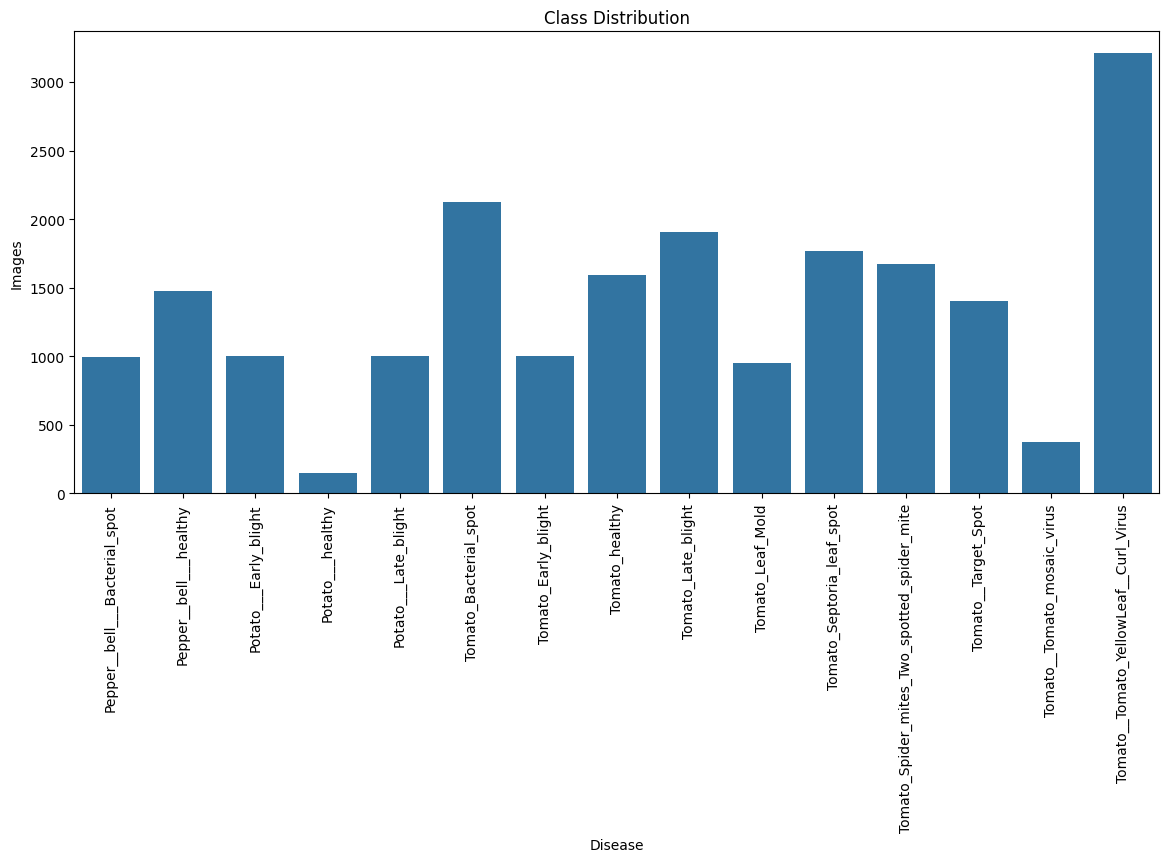

In [54]:
plt.figure(figsize=(14,6))

sns.barplot(
    x="Disease",
    y="Images",
    data=df
)

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

---

# Image Resizing

Deep learning models require all input images to have the same dimensions.

For this project, all images will be resized to 224 × 224 pixels because
VGG16 expects images of this size.

Benefits:
- Consistent input shape
- Faster training
- Compatibility with transfer learning models

In [61]:
import os
import cv2
from tqdm import tqdm

# Folder for processed images
processed_path = "processed_plantvillage"

os.makedirs(processed_path, exist_ok=True)

# VGG16 input size
IMG_SIZE = 224

# Refresh class list
classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

for class_name in tqdm(classes, desc="Processing Classes"):

    source_folder = os.path.join(dataset_path, class_name)

    destination_folder = os.path.join(
        processed_path,
        class_name
    )

    os.makedirs(
        destination_folder,
        exist_ok=True
    )

    for image_name in os.listdir(source_folder):

        image_path = os.path.join(
            source_folder,
            image_name
        )

        image = cv2.imread(image_path)

        # Skip corrupted images
        if image is None:
            continue

        # Resize image
        resized_image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        save_path = os.path.join(
            destination_folder,
            image_name
        )

        cv2.imwrite(
            save_path,
            resized_image
        )

print("All images resized successfully.")

Processing Classes: 100%|██████████████████████████████████████████████████████████████| 15/15 [02:42<00:00, 10.82s/it]

All images resized successfully.


In [63]:
sample_class = os.listdir(processed_path)[0]

sample_image = os.listdir(
    os.path.join(processed_path, sample_class)
)[0]

sample_path = os.path.join(
    processed_path,
    sample_class,
    sample_image
)

img = cv2.imread(sample_path)

print("Image Shape:", img.shape)

Image Shape: (224, 224, 3)


In [64]:
for class_name in os.listdir(processed_path):
    path = os.path.join(processed_path, class_name)
    print(class_name, ":", len(os.listdir(path)))

Pepper__bell___Bacterial_spot : 997
Pepper__bell___healthy : 1478
Potato___Early_blight : 1000
Potato___healthy : 152
Potato___Late_blight : 1000
Tomato_Bacterial_spot : 2127
Tomato_Early_blight : 1000
Tomato_healthy : 1591
Tomato_Late_blight : 1909
Tomato_Leaf_Mold : 952
Tomato_Septoria_leaf_spot : 1771
Tomato_Spider_mites_Two_spotted_spider_mite : 1676
Tomato__Target_Spot : 1404
Tomato__Tomato_mosaic_virus : 373
Tomato__Tomato_YellowLeaf__Curl_Virus : 3208


---

# Generate Processed Dataset

The processed PlantVillage dataset was created during the image resizing stage.

Tasks Completed:

- Removed corrupted images
- Preserved disease class structure
- Resized all images to 224 × 224 pixels
- Saved processed images into the `processed_plantvillage` directory

The processed dataset is now ready for model training.

Note:
Image normalization and augmentation will be applied dynamically during model training using TensorFlow/Keras preprocessing utilities.